Here we shall play around with training a DCGAN. Crazy.

In [1]:
# Imports
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import math
import matplotlib.pyplot as plt
from PIL import Image
import random
from torchvision import transforms
import torchvision.transforms.functional as TF

In [2]:
torch.manual_seed(111)

device = ""
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [3]:
# Download and unzip dataset
!kaggle datasets download -d jahysama/animal-crossing-new-horizons-all-villagers -p data
!unzip -o data/*.zip -d data

Dataset URL: https://www.kaggle.com/datasets/jahysama/animal-crossing-new-horizons-all-villagers
License(s): DbCL-1.0
100%|██████████████████████████████████████| 34.6M/34.6M [00:03<00:00, 11.2MB/s]

Archive:  data/animal-crossing-new-horizons-all-villagers.zip
  inflating: data/villagers/Ace.png  
  inflating: data/villagers/Admiral.png  
  inflating: data/villagers/Agent_S.png  
  inflating: data/villagers/Agnes.png  
  inflating: data/villagers/Al.png   
  inflating: data/villagers/Alfonso.png  
  inflating: data/villagers/Alice.png  
  inflating: data/villagers/Alli.png  
  inflating: data/villagers/Amelia.png  
  inflating: data/villagers/Anabelle.png  
  inflating: data/villagers/Anchovy.png  
  inflating: data/villagers/Angus.png  
  inflating: data/villagers/Anicotti.png  
  inflating: data/villagers/Ankha.png  
  inflating: data/villagers/Annalisa.png  
  inflating: data/villagers/Annalise.png  
  inflating: data/villagers/Antonio.png  
  inflating: data/villagers/Apollo.png  

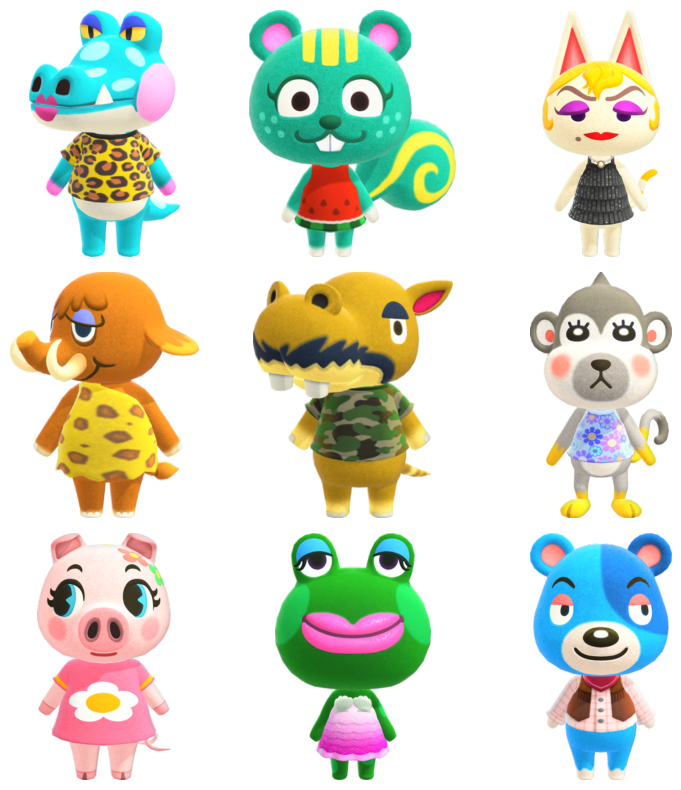

In [3]:
# Inspect the dataset
import os

base_path = "data" 
os.listdir(base_path)

image_paths = []

for root, _, files in os.walk(base_path):
    for f in files:
        if f.lower().endswith(".png"):
            image_paths.append(os.path.join(root, f))

sample_paths = random.sample(image_paths, 9)

plt.figure(figsize=(8, 8))

for i, path in enumerate(sample_paths):
    img = Image.open(path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [4]:
sizes = []

for path in image_paths:
    img = Image.open(path)
    sizes.append(img.size)

widths, heights = zip(*sizes)

print("Avg width:", sum(widths)/len(widths))
print("Avg height:", sum(heights)/len(heights))

Avg width: 216.67091836734693
Avg height: 348.82142857142856


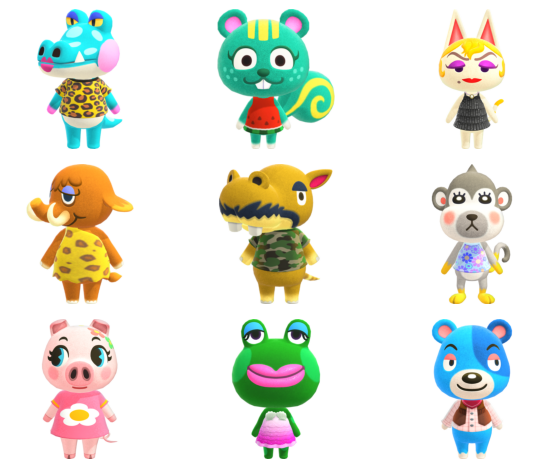

In [5]:
# Helper functions for preprocessing data

# Add white pixels to the image to make it square.
def add_padding(img):
  w, h = img.size
  largest_side = max(w, h)

  pad_left = (largest_side - w) // 2
  pad_top = (largest_side - h) // 2

  pad_right = largest_side - w - pad_left
  pad_bottom = largest_side - h - pad_top

  padding = (pad_left, pad_top, pad_right, pad_bottom)
  return TF.pad(img, padding, fill=255)
  
# Preprocesses image and returns a tensor
def preprocess_image(img):
    img = Image.open(path)
    # Handle transparent background
    if img.mode == "RGBA":
        bg = Image.new("RGB", img.size, (255, 255, 255))
        bg.paste(img, mask=img.split()[3])
        img = bg
    else:
        img = img.convert("RGB")

    # Add padding to make image square
    square_img = add_padding(img)

    # Resize and transform image to tensor
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    return transform(img)


# Visualise the padded samples. Due to transparent backgrounds we need to handle image mode.
for i, path in enumerate(sample_paths):
    img = Image.open(path)
    if img.mode == "RGBA":
        bg = Image.new("RGB", img.size, (255, 255, 255))
        bg.paste(img, mask=img.split()[3])
        img = bg
    else:
        img = img.convert("RGB")

    plt.subplot(3, 3, i + 1)
    plt.imshow(add_padding(img))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Data preparation
training_data = torch.stack([
    preprocess_image(p) for p in image_paths
])

print(training_data.shape)

batch_size = 32
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)


torch.Size([392, 3, 64, 64])


In [ ]:
# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # Add le model architecture
        )
    def forward(self, x):
        output = self.model(x)
        return output    
    
discriminator = Discriminator()    

In [33]:
# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # Le model architecture
            nn.Linear(300, 32768),
            nn.ReLU(),
            
            nn.Unflatten(1, (512, 8, 8)),
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Sigmoid()

        )

    def forward(self, x):
        output = self.model(x)
        output = output.detach()
        output = output[0].permute(1,2,0)

        return output

generator = Generator()    


In [ ]:
# Hyperparameters and optimizers
lr = 0.001
num_epochs = 300
loss_function = nn.BCELoss()

optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr) # cuz ADAM is bae <3
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

In [ ]:
# Methods for saving and loading checkpoints

# Generate a directory for the checkpoints
checkpoint_dir = './checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Saves the states of the Generator and Discriminator
def save_checkpoint(epoch):
    checkpoint_path = os.path.join(checkpoint_dir, f'epoch_{epoch}_checkpoint.pth')
    torch.save({
        'epoch': epoch,
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'optimizer_generator_state_dict': optimizer_generator.state_dict(),
        'optimizer_discriminator_state_dict': optimizer_discriminator.state_dict(),
    }, checkpoint_path)
    print(f"Checkpoint saved at {checkpoint_path}")

#Loads the latest checkpoint
def load_checkpoint():
    latest_checkpoint = max([os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir)], 
                            key=os.path.getctime, default=None)
    if latest_checkpoint:
        checkpoint = torch.load(latest_checkpoint)
        generator.load_state_dict(checkpoint['generator_state_dict'])
        discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
        optimizer_generator.load_state_dict(checkpoint['optimizer_generator_state_dict'])
        optimizer_discriminator.load_state_dict(checkpoint['optimizer_discriminator_state_dict'])
        epoch = checkpoint['epoch']
        print(f"Checkpoint restored from {latest_checkpoint}, starting at epoch {epoch + 1}")
    else:
        print("No checkpoint found. Starting training from scratch.")

In [ ]:
# Training loop
for epoch in range(num_epochs):
    # Data for training the discriminator
    # Training the discriminator
    # Data for training the generator
    # Training the generator
    # Show loss